In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os 
os.chdir('D:/Aria/T5/Expriments/bbls/code')
from uci_tests.iris.iris import Iris
from uci_tests.diabetes.diabetes import Diabetes
from uci_tests.adult.adult import Adult
from uci_tests.sonar.sonar import Sonar
from uci_tests.balance.balance import Balance
from faster_final_bls.bbls import BBLS as SVD_BBLS
from final_bls.bbls import BBLS as BBLS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from sklearn.cluster import KMeans

In [2]:
bbls = SVD_BBLS(3, 6, 10, 0.0001, 0.8, 2, 0)
X, y = Iris().get_data()
bbls.fit(X, y)

In [3]:
import matplotlib.pyplot as plt 
print(bbls.features)

[array([1, 0]), array([1, 3]), array([2, 3]), array([0, 2]), array([0, 2]), array([0, 1])]


C:\Users\parch\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


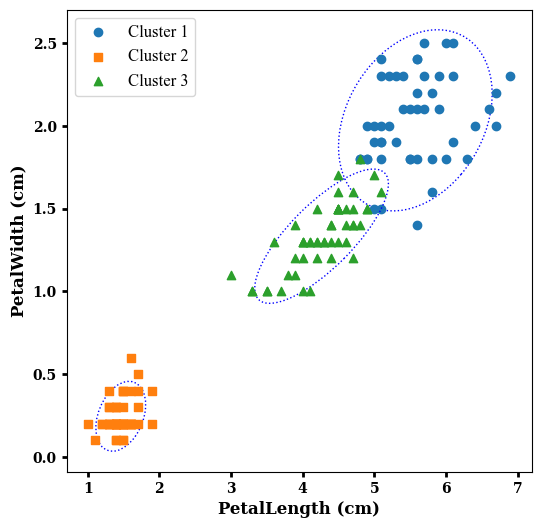

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.font_manager import FontProperties
from sklearn.cluster import KMeans
from sklearn import datasets

# Function to plot confidence ellipse
def confidence_ellipse(x, y, ax, n_std=3.0, facecolor='none', **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0),
                      width=ell_radius_x * 2,
                      height=ell_radius_y * 2,
                      facecolor=facecolor,
                      **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# Set font properties
font = {'family': 'serif', 'weight': 'bold', 'size': 12}
plt.rc('font', **font)

# Use Times font
times_font = FontProperties(fname="final_bls/times.ttf")

# Generate sample data
iris = datasets.load_iris()
X = iris.data
y = iris.target

fig, ax_nstd = plt.subplots(figsize=(6, 6))

f1, f2 = 2, 3

f_name = {
    0: 'SepalLength (cm)',
    1: 'SepalWidth (cm)',
    2: 'PetalLength (cm)',
    3: 'PetalWidth (cm)'
}

new_y = y
new_X = X[:, [f1, f2]]

new_XY = np.concatenate([new_X, new_y.reshape(-1, 1)], axis=1)

kmeans = KMeans(n_clusters=3)
kmeans.fit(new_XY)

markers = ['o', 's', '^']  # Different markers for each cluster

for i in range(3):
    xx = new_X[kmeans.labels_ == i, :]
    confidence_ellipse(xx[:, 0], xx[:, 1], ax_nstd, n_std=2, edgecolor='blue', linestyle=':')
    plt.scatter(xx[:, 0], xx[:, 1], marker=markers[i], label=f'Cluster {i + 1}')

# Set legend font properties
leg = ax_nstd.legend(prop=times_font)

ax_nstd.set_xlabel(f_name[f1], fontdict={'weight': 'bold'})
ax_nstd.set_ylabel(f_name[f2], fontdict={'weight': 'bold'})

# Set tick labels font properties
ax_nstd.tick_params(axis='both', which='both', labelsize=10, width=2)

fig.savefig('D:/Aria/T5/Expriments/bbls/code/uci_tests/iris/plt5.pdf', format='pdf')

plt.show()


C:\Users\parch\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


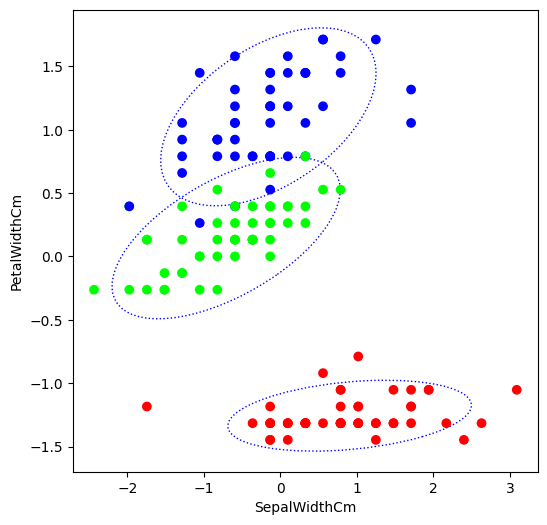

In [11]:
fig, ax_nstd = plt.subplots(figsize=(6, 6))

f1, f2 = 1,3

f_name = {
    0 : 'SepalLengthCm',
    1 : 'SepalWidthCm',
    2 : 'PetalLengthCm',
    3 : 'PetalWidthCm'
    }

new_y = y
new_X = X[:, [f1, f2]]
np.mean

new_XY = np.concatenate([new_X, new_y], axis=1)

kmeans = KMeans(n_clusters=3)
kmeans.fit(new_XY)

for i in range(3):
    xx = new_X[kmeans.labels_ == i, :]
    confidence_ellipse(xx[:,0], xx[:,1], ax_nstd, n_std=2, edgecolor='blue', linestyle=':')
    plt.scatter(xx[:,0], xx[:, 1], c=(new_y[kmeans.labels_ == i, :]))

# ax_nstd.set_title(f'rules for {f_name[f1]} and {f_name[f1]}')
ax_nstd.set_xlabel(f_name[f1])
ax_nstd.set_ylabel(f_name[f2])
fig.savefig('D:/Aria/T5/Expriments/bbls/code/uci_tests/iris/plt4.pdf', format='pdf')
plt.show()

TypeError: 'Axes' object is not iterable

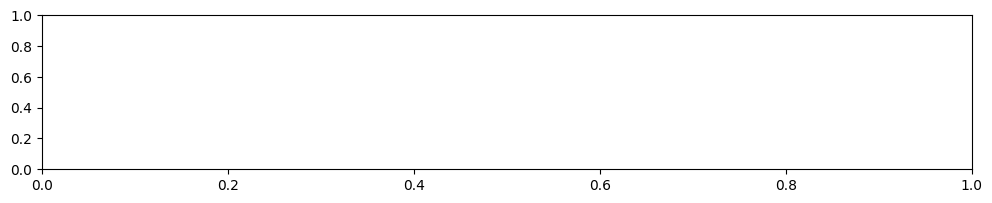

In [97]:
fig, ax_nstd = plt.subplots(1, 1, figsize=(12, 2))

fs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

for ax, (f1, f2) in zip(ax_nstd, fs):
        new_y = y
        new_X = X[:, [f1, f2]]
        np.mean

        new_XY = np.concatenate([new_X, new_y], axis=1)

        kmeans = KMeans(n_clusters=3)
        kmeans.fit(new_XY)

        for i in range(3):
            xx = new_X[kmeans.labels_ == i, :]
            confidence_ellipse(xx[:,0], xx[:,1], ax, n_std=2, label=r'$2\sigma$', edgecolor='blue', linestyle=':')
            ax.scatter(xx[:,0], xx[:, 1], c=(new_y[kmeans.labels_ == i, :]))

ax_nstd.set_title('Different standard deviations')
ax_nstd.legend()
plt.show()


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

train_accs = []
test_accs = []
for i in range(100):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i + 1)
    for train_index, test_index in kfold.split(X):
        bbls = BBLS(Nr=3, Nt=7, Ne=0, r=0.001, max_samples=1.0, max_features=2, max_iter=0)
        X_train, X_test = X[train_index, :], X[test_index, :]
        y_train, y_test = y[train_index, :], y[test_index, :]

        bbls.fit(X_train, y_train)

        y_pred = bbls.predict(X_train)
        y_pred = np.argmax(y_pred, axis=1)
        y_train = np.argmax(y_train, axis=1)
        train_acc = accuracy_score(y_train, y_pred)
        train_accs.append(train_acc)
        
        # test accuracy
        y_pred = bbls.predict(X_test)
        y_pred = np.argmax(y_pred, axis=1)
        y_test = np.argmax(y_test, axis=1)
        test_acc = accuracy_score(y_test, y_pred)
        test_accs.append(test_acc)
    
mean_train_acc = np.mean(train_accs)
mean_test_acc = np.mean(test_accs)
print('mean train acc with svd = ', mean_train_acc)
print('mean test acc with svd = ', mean_test_acc)


mean train acc with svd =  0.9622222222222223
mean test acc with svd =  0.9544666666666667


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

train_accs = []
test_accs = []
for i in range(100):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i + 1)
    for train_index, test_index in kfold.split(X):
        bbls = SVD_BBLS(Nr=3, Nt=7, Ne=0, r=0.001, max_samples=1.0, max_features=2, max_iter=0)
        X_train, X_test = X[train_index, :], X[test_index, :]
        y_train, y_test = y[train_index, :], y[test_index, :]

        bbls.fit(X_train, y_train)

        y_pred = bbls.predict(X_train)
        y_pred = np.argmax(y_pred, axis=1)
        y_train = np.argmax(y_train, axis=1)
        train_acc = accuracy_score(y_train, y_pred)
        train_accs.append(train_acc)
        
        # test accuracy
        y_pred = bbls.predict(X_test)
        y_pred = np.argmax(y_pred, axis=1)
        y_test = np.argmax(y_test, axis=1)
        test_acc = accuracy_score(y_test, y_pred)
        test_accs.append(test_acc)
    
mean_train_acc = np.mean(train_accs)
mean_test_acc = np.mean(test_accs)
print('mean train acc with svd = ', mean_train_acc)
print('mean test acc with svd = ', mean_test_acc)


mean train acc with svd =  0.9666666666666668
mean test acc with svd =  0.9598000000000001
